
# Classwork 4: Linear Processes Model (AR, MA, ARMA, ARIMA)

This lab worksheet introduces **Linear Time Series Models** including:
- Autoregressive Model (AR)
- Moving Average Model (MA)
- Autoregressive Moving Average Model (ARMA)
- Autoregressive Integrated Moving Average Model (ARIMA)
# Activity 1: Introduction to Linear Processes Model
We will demonstrate:
1. Data Preparation
2. Model Fitting
3. Forecasting
4. Visualization
5. Evaluation (MAE, RMSE, MAPE)


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Helper metric function
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


## Step 1: Create Synthetic Dataset

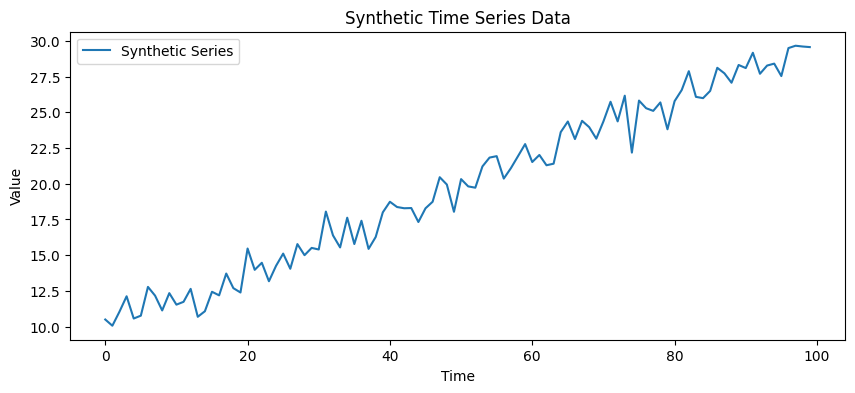

0    10.496714
1    10.061736
2    11.047689
3    12.123030
4    10.565847
dtype: float64

In [ ]:

np.random.seed(42)
n = 100
time = np.arange(n)
trend = 0.2 * time
noise = np.random.normal(0, 1, n)
series = 10 + trend + noise

plt.figure(figsize=(10,4))
plt.plot(time, series, label="Synthetic Series")
plt.title("Synthetic Time Series Data")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

data = pd.Series(series)
data.head()


## Step 2: Autoregressive Model (AR)

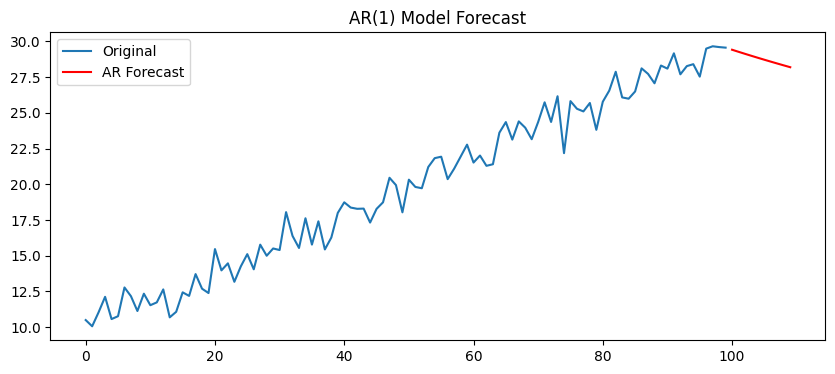

100    29.418808
101    29.274435
102    29.132257
103    28.992243
104    28.854358
105    28.718572
106    28.584851
107    28.453165
108    28.323483
109    28.195773
Name: predicted_mean, dtype: float64

In [ ]:

# Fit AR(1)
model_ar = ARIMA(data, order=(1,0,0))
result_ar = model_ar.fit()

# Forecast last 10 steps
forecast_ar = result_ar.forecast(steps=10)

plt.figure(figsize=(10,4))
plt.plot(data, label="Original")
plt.plot(range(len(data), len(data)+10), forecast_ar, label="AR Forecast", color="red")
plt.legend()
plt.title("AR(1) Model Forecast")
plt.show()

forecast_ar


## Step 3: Moving Average Model (MA)

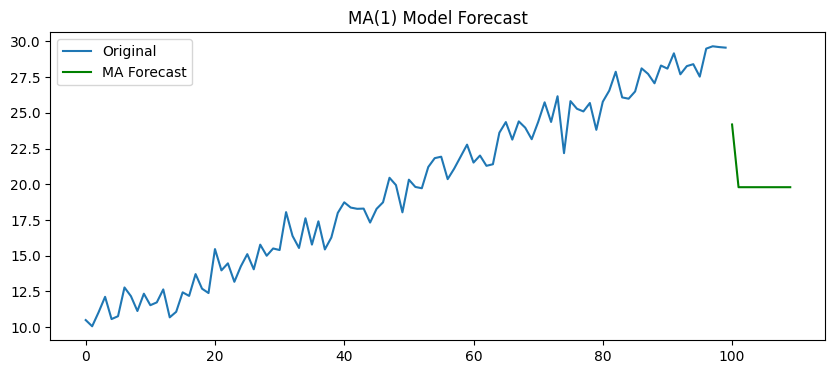

100    24.188004
101    19.796852
102    19.796852
103    19.796852
104    19.796852
105    19.796852
106    19.796852
107    19.796852
108    19.796852
109    19.796852
Name: predicted_mean, dtype: float64

In [ ]:

# Fit MA(1)
model_ma = ARIMA(data, order=(0,0,1))
result_ma = model_ma.fit()

forecast_ma = result_ma.forecast(steps=10)

plt.figure(figsize=(10,4))
plt.plot(data, label="Original")
plt.plot(range(len(data), len(data)+10), forecast_ma, label="MA Forecast", color="green")
plt.legend()
plt.title("MA(1) Model Forecast")
plt.show()

forecast_ma


## Step 4: Autoregressive Moving Average (ARMA)

c:\Users\Sahapong.S\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


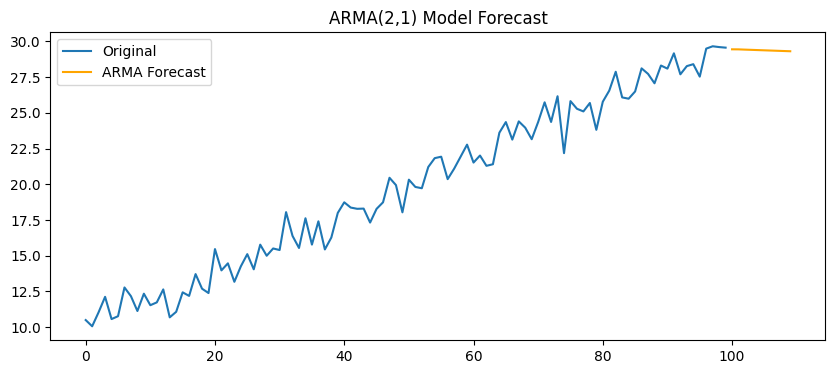

100    29.448462
101    29.444600
102    29.426680
103    29.410542
104    29.394214
105    29.377941
106    29.361692
107    29.345472
108    29.329278
109    29.313113
Name: predicted_mean, dtype: float64

In [ ]:

# Fit ARMA(2,1)
model_arma = ARIMA(data, order=(2,0,1))
result_arma = model_arma.fit()

forecast_arma = result_arma.forecast(steps=10)

plt.figure(figsize=(10,4))
plt.plot(data, label="Original")
plt.plot(range(len(data), len(data)+10), forecast_arma, label="ARMA Forecast", color="orange")
plt.legend()
plt.title("ARMA(2,1) Model Forecast")
plt.show()

forecast_arma


## Step 5: Autoregressive Integrated Moving Average (ARIMA)

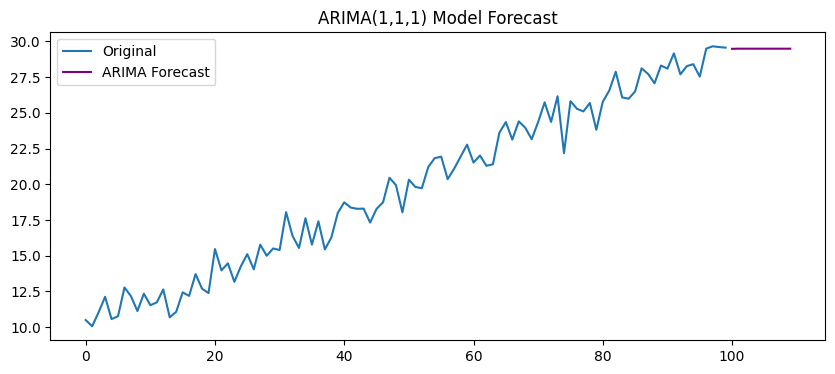

100    29.482777
101    29.493103
102    29.491813
103    29.491974
104    29.491954
105    29.491956
106    29.491956
107    29.491956
108    29.491956
109    29.491956
Name: predicted_mean, dtype: float64

In [ ]:

# Fit ARIMA(1,1,1)
model_arima = ARIMA(data, order=(1,1,1))
result_arima = model_arima.fit()

forecast_arima = result_arima.forecast(steps=10)

plt.figure(figsize=(10,4))
plt.plot(data, label="Original")
plt.plot(range(len(data), len(data)+10), forecast_arima, label="ARIMA Forecast", color="purple")
plt.legend()
plt.title("ARIMA(1,1,1) Model Forecast")
plt.show()

forecast_arima


## Step 6: Model Evaluation

c:\Users\Sahapong.S\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Sahapong.S\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Sahapong.S\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Evaluation Metrics:
MAE: 0.5834659309958272
RMSE: 0.7768911494523338
MAPE: 2.097857409883911 %


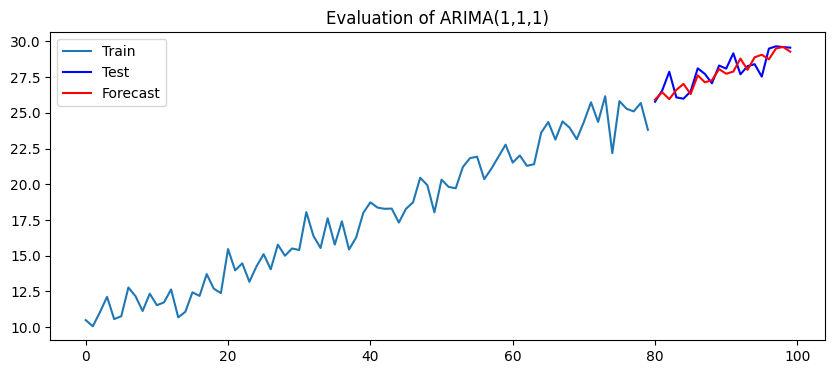

In [ ]:

# Train-test split (80-20)
train_size = int(len(data)*0.8)
train, test = data[:train_size], data[train_size:]

# Fit ARIMA for evaluation
model_eval = ARIMA(train, order=(5,2,5))
result_eval = model_eval.fit()

forecast_eval = result_eval.forecast(steps=len(test))

mae = mean_absolute_error(test, forecast_eval)
rmse = np.sqrt(mean_squared_error(test, forecast_eval))
mape_val = mape(test, forecast_eval)

print("Evaluation Metrics:")
print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape_val, "%")

plt.figure(figsize=(10,4))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test", color="blue")
plt.plot(test.index, forecast_eval, label="Forecast", color="red")
plt.legend()
plt.title("Evaluation of ARIMA(1,1,1)")
plt.show()



## คำถามการทดลอง
1. เปรียบเทียบโมเดล AR, MA, ARMA และ ARIMA โมเดลไหนที่เหมาะสมกับชุดข้อมูลนี้มากที่สุด?
2. ทำไมเราถึงใช้การหักล้างใน ARIMA?
3. ความแตกต่างหลักระหว่างโมเดล AR และ MA คืออะไร?
4. ลองเปลี่ยนลำดับของโมเดล (p,d,q) และสังเกตผลลัพธ์การคาดการณ์.
5. ค่า p,d,q ที่เหมาะสมที่ให้ค่าความคลาดเคลื่อนน้อยที่สุดคือค่าใด?


# Activity 2: LAB/Assignment: Time Series Modeling

# วัตถุประสงค์

1. ทำความเข้าใจกับข้อมูล Time Series และคุณสมบัติของ AR, MA, ARMA, ARIMA
2. เรียนรู้การสร้างโมเดลและการเลือกโมเดลที่เหมาะสม
3. เปรียบเทียบประสิทธิภาพของโมเดลด้วยตัวชี้วัดความแม่นยำ (MAE, RMSE, MAPE)

ข้อมูล : ใช้ไฟล์ synthetic_timeseries.csv (250 record)
คอลัมน์:
    Date = วันที่
    Value = ค่าตัวเลข Time Series

# กิจกรรม 1: สำรวจข้อมูล (EDA)
1. วาดกราฟ Time Series
2. ตรวจสอบแนวโน้ม (Trend), ความผันผวน (Variance), และ Seasonality
3. สร้าง Histogram, ACF, PACF ของข้อมูล

# คำถามท้ายกิจกรรม 1:
1. ข้อมูลนี้มีแนวโน้มเพิ่มขึ้นหรือลดลงหรือไม่?
2. ข้อมูลนี้เป็น stationary หรือไม่? จะตรวจสอบอย่างไร?

# ------------------------------------------------------------------------------

# กิจกรรม 2: สร้างและวิเคราะห์โมเดล AR (Autoregressive)  
*** 240 Datas for Training 
***  10 Datas for Evaluating

1. สร้างโมเดล AR(p) โดยเลือกค่าพารามิเตอร์ p = 2  (เลือกค่าพารามิเตอร์ p จาก ACF/PACF) 
2. ทำการ Forecast ข้อมูล 10 วันถัดไป แสดงกราฟเปรียบเทียบ
3. ประเมินความแม่นยำด้วย MAE, RMSE, MAPE

# คำถามท้ายกิจกรรม:
1. ค่าพารามิเตอร์ AR(p) ที่เหมาะสมคือค่าไหน?
2. โมเดล AR มีข้อจำกัดอะไรเมื่อเทียบกับโมเดลอื่น ๆ?
# ------------------------------------------------------------------------------

# กิจกรรม 3: สร้างและวิเคราะห์โมเดล MA (Moving Average)
*** 240 Datas for Training 
***  10 Datas for Evaluating
1. สร้างโมเดล MA(q)   โดยเลือกค่าพารามิเตอร์ q = 2
2. Forecast ข้อมูล 10 วันถัดไป แสดงกราฟเปรียบเทียบ
3. ประเมินความแม่นยำด้วย MAE, RMSE, MAPE

# คำถามท้ายกิจกรรม:

1. โมเดล MA(q) ให้ผลลัพธ์ดีกว่า AR(p) หรือไม่?
2. สาเหตุที่โมเดล MA เหมาะหรือไม่เหมาะกับข้อมูลนี้คืออะไร?
# ------------------------------------------------------------------------------

# กิจกรรม 4: สร้างและวิเคราะห์โมเดล ARMA (Autoregressive Moving Average)

1. สร้างโมเดล ARMA(p, q)  โดยเลือกค่าพารามิเตอร์  p=2,q=2
2. Forecast 10 วันถัดไป แสดงกราฟเปรียบเทียบ
3. ประเมินความแม่นยำด้วย MAE, RMSE, MAPE

# คำถามท้ายกิจกรรม:
1. โมเดล ARMA สามารถจับลักษณะข้อมูลได้ดีกว่า AR หรือ MA อย่างไร?
2. ค่า p และ q ที่เหมาะสมกับข้อมูลนี้คืออะไร?
# ------------------------------------------------------------------------------

# กิจกรรม 5: สร้างและวิเคราะห์โมเดล ARIMA (Autoregressive Integrated Moving Average)

1. ตรวจสอบความ Stationary ของข้อมูล
2. ถ้าจำเป็น ให้ทำ Differencing (d)
3. สร้างโมเดล ARIMA(p, d, q)        
4. Forecast 10 วันถัดไป  แสดงกราฟเปรียบเทียบ
5. ประเมินความแม่นยำด้วย MAE, RMSE, MAPE

# คำถามท้ายกิจกรรม:

1. โมเดล ARIMA ให้ผลลัพธ์ดีกว่าโมเดลอื่นหรือไม่?
2. เลือกโมเดล ARIMA(p, d, q) อย่างไร?
# ------------------------------------------------------------------------------

# กิจกรรม 6: สรุปผลและเลือกโมเดลที่เหมาะสม
1. แสดงกราฟเปรียบเทียบโมเดล AR, MA, ARMA, ARIMA ในการ Forcast 10 วันถัดไป
2. สรุปว่าโมเดลใดเหมาะสมที่สุดกับข้อมูล synthetic_timeseries.csv และเพราะเหตุใด

# คำถามท้ายกิจกรรม:

1. โมเดลใดเหมาะสมที่สุด และเหตุผลทางสถิติ
